# Post Lab: Data Preprocessing on Titanic Dataset

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split


## 2. Load Dataset

In [ ]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Dataset Information

In [ ]:
print(df.shape)
print(df.columns)
df.info()

(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alo

## 4. Statistical Summary

In [ ]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Check Missing Values

In [ ]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 6. Handle Missing Values

In [ ]:

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])


df["deck"] = df["deck"].cat.add_categories(["Unknown"])  
df["deck"] = df["deck"].fillna("Unknown")  

df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

## 7. Remove Unnecessary Columns

In [ ]:
df=df.drop(columns=["alive","class","who","adult_male","alone"])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck,embark_town
0,0,3,male,22.0,1,0,7.2500,S,Unknown,Southampton
1,1,1,female,38.0,1,0,71.2833,C,C,Cherbourg
2,1,3,female,26.0,0,0,7.9250,S,Unknown,Southampton
3,1,1,female,35.0,1,0,53.1000,S,C,Southampton
4,0,3,male,35.0,0,0,8.0500,S,Unknown,Southampton


## 8. Encode Categorical Variables

In [ ]:
le=LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col]=le.fit_transform(df[col])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck,embark_town
0,0,3,1,22.0,1,0,7.2500,2,Unknown,2
1,1,1,0,38.0,1,0,71.2833,0,C,0
2,1,3,0,26.0,0,0,7.9250,2,Unknown,2
3,1,1,0,35.0,1,0,53.1000,2,C,2
4,0,3,1,35.0,0,0,8.0500,2,Unknown,2


## 9. Remove Duplicate Records

In [ ]:
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates()
print("New Shape:",df.shape)

Duplicates: 110
New Shape: (781, 10)


## 10. Min-Max Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler


df = df.replace('Unknown', np.nan)
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

mm = MinMaxScaler()
df[numeric_columns] = mm.fit_transform(df[numeric_columns])

df.head()

C:\Users\nvs_p\AppData\Local\Temp\ipykernel_48416\1285325986.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace('Unknown', np.nan)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck,embark_town
0,0.0,1.0,1.0,0.271174,0.125,0.0,0.014151,1.0,NaN,1.0
1,1.0,0.0,0.0,0.472229,0.125,0.0,0.139136,0.0,C,0.0
2,1.0,1.0,0.0,0.321438,0.000,0.0,0.015469,1.0,NaN,1.0
3,1.0,0.0,0.0,0.434531,0.125,0.0,0.103644,1.0,C,1.0
4,0.0,1.0,1.0,0.434531,0.000,0.0,0.015713,1.0,NaN,1.0


## 11. Log Transformation

In [ ]:
df["Fare_Log"]=np.log1p(df["fare"])
df[["fare","Fare_Log"]].head()

,fare,Fare_Log
0,0.014151,0.014052
1,0.139136,0.130270
2,0.015469,0.015350
3,0.103644,0.098618
4,0.015713,0.015590


## 12. Correlation Heatmap

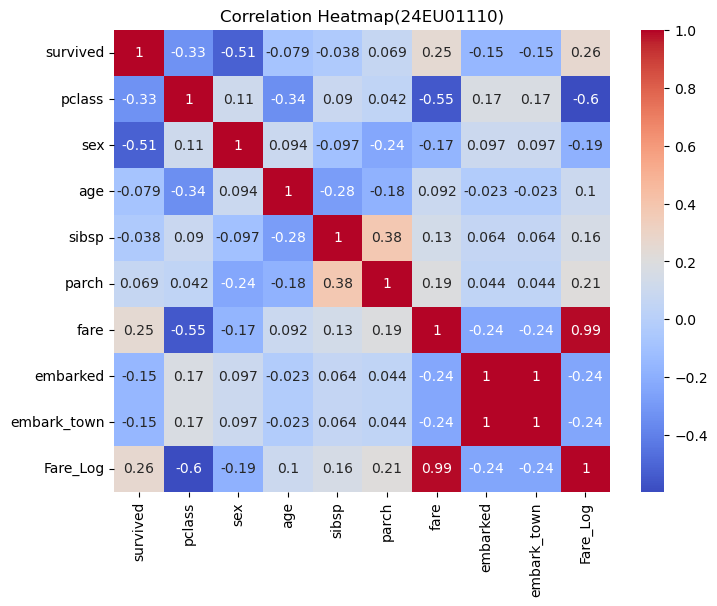

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title(f"Correlation Heatmap(24EU01110)")
plt.show()

## 13. Feature and Target Separation

In [ ]:
X=df.drop("survived",axis=1)
y=df["survived"]
print(X.shape)
print(y.shape)

(781, 10)
(781,)


## 14. Train-Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(624, 10)
(157, 10)


## 15. Standard Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train_scaled = sc.fit_transform(X_train[numerical_columns])
X_test_scaled = sc.transform(X_test[numerical_columns])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_columns)

X_train_scaled_df.head()


,pclass,sex,age,sibsp,parch,fare,embarked,embark_town,Fare_Log
0,-0.274353,0.766672,0.326332,-0.531473,-0.504627,-0.408550,0.586428,0.586428,-0.447945
1,0.898223,-1.304338,-0.406133,0.467440,-0.504627,-0.356163,0.586428,0.586428,-0.383364
2,0.898223,0.766672,-0.113147,-0.531473,-0.504627,-0.505435,-0.654016,-0.654016,-0.568309
3,-0.274353,-1.304338,-0.625872,-0.531473,-0.504627,-0.454504,0.586428,0.586428,-0.504884
4,-0.274353,0.766672,0.472824,0.467440,1.899092,-0.137425,0.586428,0.586428,-0.117425
